In [187]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyampute.exploration.mcar_statistical_tests import MCARTest
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, FunctionTransformer, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, GroupKFold, GridSearchCV
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("data/Life Expectancy Data.csv")
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_").str.replace('/', '_').str.replace('-', '_')
df.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
df.describe()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [177]:
df.info()

<class 'pandas.DataFrame'>
Index: 2928 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          2928 non-null   str    
 1   year                             2928 non-null   int64  
 2   status                           2928 non-null   str    
 3   life_expectancy                  2928 non-null   float64
 4   adult_mortality                  2928 non-null   float64
 5   infant_deaths                    2928 non-null   int64  
 6   alcohol                          2735 non-null   float64
 7   percentage_expenditure           2928 non-null   float64
 8   hepatitis_b                      2375 non-null   float64
 9   measles                          2928 non-null   int64  
 10  bmi                              2896 non-null   float64
 11  under_five_deaths                2928 non-null   int64  
 12  polio                            290

In [5]:
(df.isnull().mean()*100).sort_values(ascending=False) 

population                         22.191967
hepatitis_b                        18.822328
gdp                                15.248468
total_expenditure                   7.692308
alcohol                             6.603131
income_composition_of_resources     5.684139
schooling                           5.547992
thinness__1_19_years                1.157250
thinness_5_9_years                  1.157250
bmi                                 1.157250
diphtheria                          0.646698
polio                               0.646698
life_expectancy                     0.340368
adult_mortality                     0.340368
infant_deaths                       0.000000
status                              0.000000
country                             0.000000
year                                0.000000
under_five_deaths                   0.000000
measles                             0.000000
percentage_expenditure              0.000000
hiv_aids                            0.000000
dtype: flo

In [158]:
df = df.dropna(subset=['life_expectancy'])

<h4>that means the data is heavily skewed towards the Developing Countries</h4>

It can be a problem if the training data has only few Developed Countries

---

<h4>Let's first Decide if the data is MCAR/MAR/MNAR </h4>

---

To decide that let's create a function that takes the df and returns the imputed df

In [170]:
def check_missingness(df: pd.DataFrame) -> pd.DataFrame:

    treated_df = df.copy()

    encoded_df = df.copy()


    # Temparory Encoding 
    label_encoders = {}
    for col in encoded_df.select_dtypes(include=['object']).columns.tolist():
        label_encoders[col] = LabelEncoder()
        
        encoded_df[col] = label_encoders[col].fit_transform(encoded_df[col])
    

    # Identify the Features with no Null values 
    missing_percentages = df.isnull().mean()

    complete_features = missing_percentages[missing_percentages == 0].index.tolist()

    # If No column are 100% complete pick columns with <1% missingness
    if len(complete_features) < 2:
        complete_features = missing_percentages[missing_percentages < 0.01].index.tolist()

        encoded_df = encoded_df.dropna(subset = complete_features)
    
    # print("Running MCAR Test....")
    mcar_test = MCARTest()
    p_value = mcar_test(df.select_dtypes(exclude=['object']))
    # print(f"p value : {p_value}")

    # If p_value > 0.05 means Null Hypothesis is Correct Data is MCAR
    if p_value > 0.05: 
        # Treat as MCAR
        # print("Data is MCAR")
        num_cols = treated_df.select_dtypes(exclude=['object']).columns.tolist()

        for col in num_cols:
            if treated_df[col].isnull().any():
                treated_df[col] = treated_df[col].fillna(treated_df[col].median())
        return treated_df

    # If p_value < 0.05 
    # print("Data is Not MCAR")
    # print("Checking btw MAR and MNAR")

    columns_to_test = missing_percentages[missing_percentages > 0].index.tolist()
    mar_cols = []
    mnar_cols = []

    # Removing the country columns because lower gdp and population countries will never give there name so my model don't learn it memorize that if this country came the value will be missing 
    complete_features.remove('country')

    # Checking each row individually
    for col in columns_to_test:

        pct = missing_percentages[col]*100

        # if missing values are <1% then just fill it with mean or median
        if pct < 1:
            treated_df[col] = treated_df[col].fillna(treated_df[col].median())
            continue

        # creating a missing indicator for model
        encoded_df['is_missing'] = encoded_df[col].isnull().astype(int) 
        
        X = encoded_df[complete_features]
        y = encoded_df['is_missing']

        clf = RandomForestClassifier(n_estimators=100, random_state=0)

        scores = cross_val_score(clf, X, y, cv = 5, scoring='roc_auc')

        mean_auc = scores.mean()
        # print(f"AUC for {col} : {mean_auc}")
        # If mean_auc >= 0.70 the columns has high relation and will be added to mar_cols
        if mean_auc >= 0.70:
            mar_cols.append(col)
        # if not then it is suspected to be MNAR and need to add missing indicator
        else:
            treated_df[f"{col}_was_missing"] = treated_df[col].isnull().astype(int)
            mnar_cols.append(col)
    # print(f"MAR Columns : {mar_cols}")
    # print(f"MNAR Columns : {mnar_cols}")
    # Imputation for MAR/MNAR columns
    if mar_cols or mnar_cols:
        num_cols = treated_df.select_dtypes(exclude='object').columns.tolist()

        mice = IterativeImputer(max_iter=50, random_state=0, min_value=0)

        treated_df[num_cols] = mice.fit_transform(treated_df[num_cols])
    # print("Data Imputation is complete")
    return treated_df.drop(columns=['country'])  

In [91]:
imputed_df = check_missingness(df)

C:\Users\Keval\AppData\Local\Temp\ipykernel_2452\304497978.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in encoded_df.select_dtypes(include=['object']).columns.tolist():


Running MCAR Test....
p value : 0.0
Data is Not MCAR
Checking btw MAR and MNAR
AUC for alcohol : 0.9833339451809312
AUC for hepatitis_b : 0.7965645233569761
AUC for bmi : 0.7993462378719663
AUC for total_expenditure : 0.967533871135012
AUC for gdp : 0.990176235528882
AUC for population : 0.8519782532839745
AUC for thinness__1_19_years : 0.7993462378719663
AUC for thinness_5_9_years : 0.7993462378719663
AUC for income_composition_of_resources : 0.8549804218396275
AUC for schooling : 0.8607807807807808
MAR Columns : ['alcohol', 'hepatitis_b', 'bmi', 'total_expenditure', 'gdp', 'population', 'thinness__1_19_years', 'thinness_5_9_years', 'income_composition_of_resources', 'schooling']
MNAR Columns : []
Data Imputation is complete


In [57]:
print(imputed_df.isnull().sum().sum())
imputed_df.describe()

0


,year,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
count,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2.938000e+03,2938.000000,2938.000000,2938.000000,2938.000000
mean,2007.518720,69.234717,164.725664,30.303948,4.523402,738.251295,78.399502,2419.592240,38.137164,42.035739,82.617767,5.918995,82.393125,1.742103,6671.649854,1.200235e+07,4.851779,4.883821,0.625516,11.977571
std,4.613841,9.509115,124.086215,117.926501,3.966290,1987.914858,25.162955,11467.272489,20.018815,160.445548,23.367166,2.416671,23.655562,5.077785,13292.168109,5.399839e+07,4.396132,4.484689,0.210648,3.369045
min,2000.000000,36.300000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,0.000000,0.000000e+00,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.200000,74.000000,0.000000,0.930000,4.685343,72.000000,0.000000,19.300000,0.000000,78.000000,4.340000,78.000000,0.100000,462.494371,3.826485e+05,1.600000,1.600000,0.488000,10.000000
50%,2008.000000,72.100000,144.000000,3.000000,3.710955,64.912906,88.358776,17.000000,43.000000,4.000000,93.000000,5.730000,93.000000,0.100000,1848.418800,2.995117e+06,3.400000,3.400000,0.675500,12.300000
75%,2012.000000,75.600000,227.000000,22.000000,7.417500,441.534144,96.000000,360.250000,56.100000,28.000000,97.000000,7.340000,97.000000,0.800000,5069.261351,8.697074e+06,7.100000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.021025,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.956213,20.700000


<h4>
So even after  imputation there are column that are Highly Correlated So now let's fix them
</h4>

In [110]:
vif = pd.DataFrame()
vif['column'] = imputed_df.drop(columns=['status', 'life_expectancy']).columns
vif['vif'] = [variance_inflation_factor(imputed_df.drop(columns=['status', 'life_expectancy']).values,i) for i in range(imputed_df.drop(columns=['status', 'life_expectancy']).shape[1])]
vif

,column,vif
0,year,54.338754
1,adult_mortality,4.931311
2,infant_deaths,189.703789
3,alcohol,4.044510
4,percentage_expenditure,6.630719
5,hepatitis_b,23.022873
6,measles,1.439397
7,bmi,8.305358
8,under_five_deaths,189.257367
9,polio,27.083066


<h4> There are still high correlatio btw (infant_death and under_five_deaths), (polio, diphetheria and hepatitis_b) and (thinness__1_19_years and thinnes_5_9_years)<br>
So let's fix them<br>

gdp, scholling and income_composition_of_resource are common let the Ridge Regressor held it. After all that's why the Ridge Regressor is used 
</h4>



In [108]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.pca = PCA(n_components=1)
        self.vax_scaler = StandardScaler()

    def fit(self, X, y=None):
        X = X.copy()
        self.ratio_median = (X['infant_deaths'] / X['under_five_deaths'].replace(0, np.nan)).median()
        vax_cols = X[['polio', 'diphtheria', 'hepatitis_b']]
        vax_scaled = self.vax_scaler.fit_transform(vax_cols)
        self.pca.fit(vax_scaled)
        return self

    def transform(self, X):
        X = X.copy()

        X['under_five_death_ratio'] = X['infant_deaths'] / X['under_five_deaths'].replace(0, np.nan)

        # Since we added the NaN in the under_five_death_ratio we need to Fill that 
        X['under_five_death_ratio'] = X['under_five_death_ratio'].fillna(self.ratio_median)
        X = X.drop(columns=['infant_deaths', 'under_five_deaths'])

        X['thinness_index'] = X[['thinness__1_19_years', 'thinness_5_9_years']].mean(axis=1)
        X = X.drop(columns=['thinness__1_19_years', 'thinness_5_9_years'])

        vax_cols = X[['polio', 'diphtheria', 'hepatitis_b']]
        vax_scaled = self.vax_scaler.transform(vax_cols)
        X['vaccination_coverage_avg'] = self.pca.transform(vax_scaled)
        
        X = X.drop(columns=['polio', 'diphtheria', 'hepatitis_b'])

        return X

In [111]:
fe = FeatureEngineer()
engineered_df = fe.fit_transform(imputed_df)

In [114]:
vif = pd.DataFrame()
vif['column'] = engineered_df.drop(columns=['status', 'life_expectancy']).columns
vif['vif'] = [variance_inflation_factor(engineered_df.drop(columns=['status', 'life_expectancy']).values,i) for i in range(engineered_df.drop(columns=['status', 'life_expectancy']).shape[1])]
vif.sort_values(by='vif', ascending=False)

,column,vif
0,year,64.906621
11,schooling,52.685810
10,income_composition_of_resources,31.450776
12,under_five_death_ratio,24.682105
6,total_expenditure,8.576134
5,bmi,8.319558
8,gdp,7.584500
3,percentage_expenditure,6.569800
1,adult_mortality,4.933903
13,thinness_index,4.012026


---

<h4> Now that the data is imputed lets talk about Outliers </h4>

---

In [127]:
imputed_df[['year', 'percentage_expenditure', 'gdp']].sort_values(
'percentage_expenditure', ascending=False
).head(10)

,year,percentage_expenditure,gdp
2522,2014.0,19479.91161,85814.58857
2523,2013.0,19099.04506,84658.88768
1545,2008.0,18961.34860,114293.84330
2525,2011.0,18822.86732,87998.44468
2524,2012.0,18379.32974,83164.38795
1542,2011.0,17028.52798,115761.57700
1539,2014.0,16255.16198,119172.74180
1540,2013.0,15515.75234,113751.85000
1547,2006.0,15345.49070,89739.71170
1915,2010.0,15268.06445,87646.75346


In [ ]:
q1 = imputed_df.select_dtypes(exclude='object').quantile(0.25)
q3 = imputed_df.select_dtypes(exclude='object').quantile(0.75)
IQR = q3 - q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

outlier = imputed_df[(imputed_df.select_dtypes(exclude='object') < lower) | (imputed_df.select_dtypes(exclude='object') > upper)]


,year,life_expectancy,adult_mortality,alcohol,percentage_expenditure,measles,bmi,total_expenditure,hiv_aids,gdp,population,income_composition_of_resources,schooling,under_five_death_ratio,thinness_index,vaccination_coverage_avg
count,0.0,17.000000,86.000000,2.00000,389.000000,542.000000,0.0,45.000000,542.000000,420.000000,3.020000e+02,130.0,40.000000,71.000000,104.000000,177.000000
mean,NaN,42.894118,551.209302,17.59000,4527.284867,12749.365314,NaN,13.961778,8.386716,33215.637066,8.003155e+07,0.0,0.942500,0.051675,19.152885,-4.159080
std,NaN,2.304743,76.898270,0.39598,3596.995227,24138.489847,NaN,1.872660,9.233008,19470.982186,1.518719e+08,0.0,1.465481,0.146331,3.980632,0.786380
min,NaN,36.300000,457.000000,17.31000,1099.248837,908.000000,NaN,11.870000,1.900000,11984.868570,2.131968e+07,0.0,0.000000,0.000000,15.250000,-5.491465
25%,NaN,42.300000,485.000000,17.45000,1871.736563,1836.500000,NaN,12.240000,2.900000,16578.581848,2.799053e+07,0.0,0.000000,0.000000,16.087500,-5.090365
50%,NaN,43.800000,527.000000,17.59000,3343.026219,4223.000000,NaN,13.660000,4.850000,28822.324785,4.335170e+07,0.0,0.000000,0.000000,18.100000,-3.887312
75%,NaN,44.500000,608.000000,17.73000,6191.211908,11224.250000,NaN,15.270000,9.250000,44362.824725,6.951030e+07,0.0,2.900000,0.000000,19.600000,-3.450660
max,NaN,44.600000,723.000000,17.87000,19479.911610,212183.000000,NaN,17.600000,50.600000,119172.741800,1.293859e+09,0.0,3.500000,0.490909,28.150000,-3.173967


In [ ]:
for col in imputed_df.select_dtypes(exclude=['object']).columns:
    sns.boxplot(imputed_df[col], label = col)
    plt.title(col)
    plt.show()

In [171]:
imputer = FunctionTransformer(func=check_missingness)

status_encoder_pipe = Pipeline(steps = [
    ('encode', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

scaler_pipe = Pipeline(steps = [
    ('scaler', StandardScaler())
])

positive_skewness_pipe = Pipeline(steps = [
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

negative_skewness_pipe = Pipeline(steps = [
    ('square', FunctionTransformer(func=np.square, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

heavy_skewness_pipe = Pipeline(steps = [
    ('yeo-johnson', PowerTransformer(method='yeo-johnson'))
])

In [128]:
skewness = engineered_df.skew(numeric_only=True).sort_values(ascending=False)
skewness

population                         17.902832
measles                             9.441332
hiv_aids                            5.396112
percentage_expenditure              4.652051
gdp                                 3.532959
thinness_index                      1.743725
adult_mortality                     1.177899
total_expenditure                   0.645672
alcohol                             0.627157
year                               -0.006409
bmi                                -0.199769
schooling                          -0.573478
life_expectancy                    -0.642391
income_composition_of_resources    -1.088182
vaccination_coverage_avg           -1.577891
under_five_death_ratio             -1.844789
dtype: float64

In [ ]:
positive_skewness_cols = skewness[(skewness>0.5) & (skewness<1)].index.tolist()
negative_skewness_cols = skewness[(skewness<-0.5) & (skewness>-1)].index.tolist()
negative_skewness_cols.remove('life_expectancy')
heavy_skewness_cols = skewness[(skewness > 1) | (skewness < -1)].index.tolist()

(2, 1, 10)

In [ ]:
transformer = ColumnTransformer(transformers=[
    ('status_encoder', status_encoder_pipe, ['status']),
    ('positive_skewness', positive_skewness_pipe, positive_skewness_cols),
    ('negative_skewness', negative_skewness_pipe, negative_skewness_cols),
    ('heavy_skewness', heavy_skewness_pipe, heavy_skewness_cols),
    ("scaler", scaler_pipe, ['year', 'bmi'])
], remainder='passthrough', verbose_feature_names_out=False)

In [145]:
transformer.fit(engineered_df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('status_encoder', ...), ('positive_skewness', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transforme

In [147]:
transformed_df = pd.DataFrame(transformer.transform(engineered_df),
                              columns=transformer.get_feature_names_out())
transformed_df.skew()

status_Developing                 -1.718238
total_expenditure                 -0.663748
alcohol                           -0.288523
schooling                          0.374502
population                        -0.001149
measles                            0.180945
hiv_aids                           0.969222
percentage_expenditure            -0.014371
gdp                                0.018246
thinness_index                     0.009532
adult_mortality                   -0.079300
income_composition_of_resources   -0.151172
vaccination_coverage_avg          -0.364006
under_five_death_ratio             0.079290
year                              -0.006409
bmi                               -0.199769
life_expectancy                   -0.642391
dtype: float64

In [179]:
final_model = Pipeline(steps = [
    ('imputation', imputer),
    ("engineering", FeatureEngineer()),
    ('transformer', transformer),
    ('ridge', Ridge(alpha=5, solver='cholesky'))
])

In [173]:
X = df.drop(columns=['life_expectancy'])
y = df['life_expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size = 0.3)

In [174]:
final_model.fit(X_train, y_train)

C:\Users\Keval\AppData\Local\Temp\ipykernel_2452\4006691509.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in encoded_df.select_dtypes(include=['object']).columns.tolist():


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputation', ...), ('feature_engineer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function che...001A710D393A0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword argu

In [175]:
pred = final_model.predict(X_test)

r2_score(y_test, pred)

C:\Users\Keval\AppData\Local\Temp\ipykernel_2452\4006691509.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in encoded_df.select_dtypes(include=['object']).columns.tolist():


0.8245113806414576

<h4>
Now let's find the best value of alpha using GridSearchCV
</h4>

In [184]:
params = {'ridge__alpha' : [100, 500, 1000, 5000]}

group_kfolds = GroupKFold(n_splits=5)

grid_search = GridSearchCV(
    estimator=final_model,
    param_grid=params,
    scoring='r2',
    cv=group_kfolds
)

grid_search.fit(
    X_train, 
    y_train, 
    groups=df.loc[X_train.index, 'country']
)

C:\Users\Keval\AppData\Local\Temp\ipykernel_2452\4006691509.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in encoded_df.select_dtypes(include=['object']).columns.tolist():
C:\Users\Keval\AppData\Local\Temp\ipykernel_2452\4006691509.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.o

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'cholesky'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [100, 500, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;

In [185]:
grid_search.best_params_

{'ridge__alpha': 100}

In [186]:
grid_search.best_score_

np.float64(0.8226673436534517)

C:\Users\Keval\AppData\Local\Temp\ipykernel_2452\4006691509.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in encoded_df.select_dtypes(include=['object']).columns.tolist():


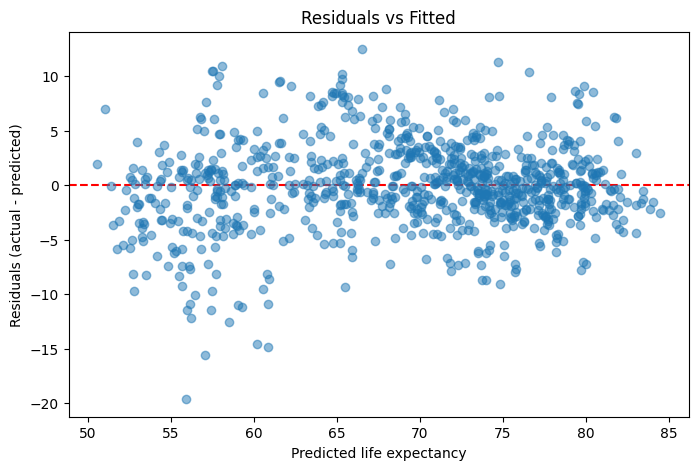

In [188]:
y_pred = grid_search.best_estimator_.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5, zorder=3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted life expectancy')
plt.ylabel('Residuals (actual - predicted)')
plt.title('Residuals vs Fitted')
plt.show()